In [14]:
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import transforms

from torch.utils.data import TensorDataset, DataLoader

import torch
import torch.nn as nn
import torch.optim as optim

## MNIST DATAset
it use **Grayscale (1 channel)** formate  
with resolution: 28x28 pixels  
each pixel Value: ranging from **0(black)** to **255 (white)**.

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [16]:
transform = transforms.Compose([
    transforms.ToTensor(), # auto scales [0, 255] to [0.0, 1.0]
])

In [17]:
# download dataset 
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

## Make DataLoader

In [18]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

## Build CNN

In [19]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # COnvolutional Layer: Feature Extraction
        self.conv_layer = nn.Sequential(
            # 1st block: (28, 28, 1) -> (28, 28, 32) -> (14, 14, 32)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # slide small filters across the image to detect basic visual
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 2nd block: (14, 14, 32) -> (14, 14, 64) -> (7, 7, 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 3rd block: (7, 7, 64) -> (7, 7, 128) -> (3, 3, 128)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Output: (batch_size, 128, 3, 3)

            # fixed overfitting (regularization)
            nn.Dropout(0.25),
            
            # total flattened features : 3x3x128 = 1152
            # Flattens (batch_size, 128, 3, 3) => (batch_size, 1152)
            nn.Flatten()
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(in_features=128*3*3, out_features=256),
            nn.ReLU(),

            nn.Linear(in_features=256, out_features=10)
            # softmax auto apply by CrossEntopy
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x


In [20]:
cnn_model = CNN()
cnn_model = cnn_model.to(device)

### Model Output when we pass images
output shape: [256, 10] 
- 256: The number of images processed in this specific batch
- 10: The 10 possible digit classes (numbers 0 through 9)  

Each row in that tensor corresponds to one image, and it contains 10 floating-point numbers

model returns logits for every images:  
outputs (for one image) = [-1.2,  0.5,  -3.1,  6.8,  1.1,  -0.4,  -2.1,  0.2,  -1.5,  0.8] 

Higher number = The model is highly confident the image belongs to that class index.
Lower number = The model thinks it is highly unlikely to be that class.

## Define Loss function & Optimizer

In [21]:
cnn_criterian = nn.CrossEntropyLoss()  # work dirctly with raw digits, auto use Softmax

# images are not zero-centered, because we scaled input data [0.0, 1.0] 
# So take lower learning rate to ensure steady training
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

## TRain Model

In [22]:
epochs = 10
cnn_train_losses = []
cnn_val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):
    cnn_model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        cnn_optimizer.zero_grad()

        outputs = cnn_model(images) # model return logits for all images
        # _, predicted_digits = torch.max(outputs, dim=1) # predicted_digits.shape = torch.size([256])
        loss = cnn_criterian(outputs, labels)
        loss.backward() 
        cnn_optimizer.step() # update weights

        running_train_loss += loss.item()
    
    epoch_train_loss = running_train_loss / len(train_loader)
    cnn_train_losses.append(epoch_train_loss)

    cnn_model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = cnn_model(images)
            loss = cnn_criterian(outputs, labels)
            running_val_loss += loss.item()
        
        epoch_val_loss = running_val_loss / len(test_loader)
        cnn_val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}: train_loss={epoch_train_loss} & val_loss={epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(cnn_model.state_dict(), "best_cnn_model.pt")

epoch 1/10: train_loss=0.18028778759842076 & val_loss=0.0477165864931811
epoch 2/10: train_loss=0.0499972920252461 & val_loss=0.04163318645015543
epoch 3/10: train_loss=0.03803335687003857 & val_loss=0.02455009585040446
epoch 4/10: train_loss=0.02955046598594745 & val_loss=0.025170448850823646
epoch 5/10: train_loss=0.024874997795750906 & val_loss=0.021794587798004108
epoch 6/10: train_loss=0.019389608498987382 & val_loss=0.04240065659142445
epoch 7/10: train_loss=0.017134567946952985 & val_loss=0.022383150311829605
epoch 8/10: train_loss=0.014749249352997582 & val_loss=0.02526384154138486
epoch 9/10: train_loss=0.013550114689791068 & val_loss=0.024966352177400973
epoch 10/10: train_loss=0.012011718300703219 & val_loss=0.031248875988701876


## Validation

In [23]:
cnn_model.eval()

total_labels = 0
correct_labels = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = cnn_model(images)
        _, predicted_digits = torch.max(outputs, dim=1) # predicted_digits.shape = torch.size([256])

        total_labels += len(labels)
        correct_labels += (predicted_digits==labels).sum().item()

print(f"Total = {total_labels}")
print(f"currect = {correct_labels}")
print(f"Accuracy = {100 * correct_labels/total_labels}")

Total = 10000
currect = 9919
Accuracy = 99.19


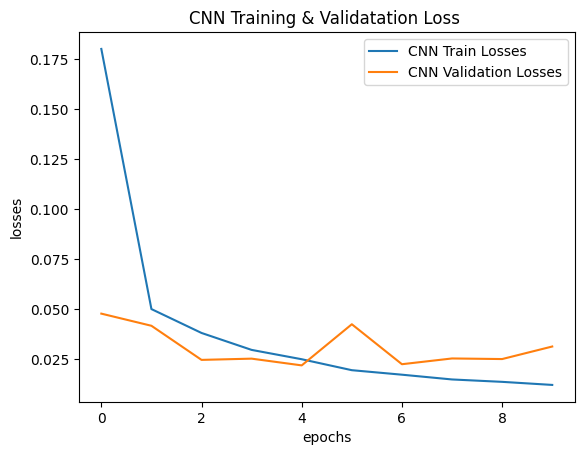

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

cnn_losses_df = pd.DataFrame({
    "CNN Train Losses": cnn_train_losses,
    "CNN Validation Losses": cnn_val_losses
})

plt.plot(cnn_losses_df['CNN Train Losses'], label='CNN Train Losses')
plt.plot(cnn_losses_df['CNN Validation Losses'], label='CNN Validation Losses')

plt.title("CNN Training & Validatation Loss ")

plt.xlabel("epochs")
plt.ylabel("losses")

plt.legend()
